# 🇻🇳 LSTM Transfer Learning v3 — Fine-tuning trên dữ liệu Việt Nam

**FIX theo chuẩn transfer_learning_v3 (TFT):**
- ✅ Preprocessing VN: shift weather + đầy đủ features như global model
- ✅ **2-Phase fine-tuning** (thay vì freeze đơn giản)
  - Phase 1 (15 epoch): Freeze rnn → chỉ train head, LR=3e-4
  - Phase 2 (30 epoch): Unfreeze toàn bộ → full fine-tune, LR=3e-5
- ✅ Metrics đầy đủ: MAE, RMSE, SMAPE, WAPE, MAPE, R²
- ✅ Loại series 'Other fossil' (nhiều zeros)

---
| Thông số | Giá trị |
|---|---|
| Pretrained | `checkpoint/lstm_v3_best.ckpt` |
| VN data | 2019-01 → 2024-12 (72 tháng) |
| Series fine-tune | Coal, Gas, Hydro, Solar, Wind |
| Phase 1 LR | 3e-4 (frozen rnn) |
| Phase 2 LR | 3e-5 (full unfreeze) |

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, json
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models.rnn import RecurrentNetwork
from pytorch_forecasting.metrics import MAE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'.')
VN_MAIN_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'full_vietnam_monthly.csv'
VN_WEATHER_PATH= BASE_DIR / 'data' / 'processed' / 'VN_data' / 'full_weather_vietnam_monthly.csv'
PRETRAIN_CKPT  = BASE_DIR / 'checkpoint' / 'lstm_v3_best.ckpt'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'lstm_vn_v3'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Pretrain ckpt: {PRETRAIN_CKPT}')
print(f'Exists       : {PRETRAIN_CKPT.exists()}')

PyTorch : 2.5.1+cu121
Device  : cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)
Pretrain ckpt: checkpoint\lstm_v3_best.ckpt
Exists       : True


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (2-Phase, giống transfer_learning_v3)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    max_encoder_length    = 24,
    max_prediction_length = 6,
    min_series_length     = 30,
    val_cutoff_months     = 12,

    # ── Model — giữ nguyên kiến trúc từ pretrained ────────────────────────────
    hidden_size           = 32,
    rnn_layers            = 2,
    dropout               = 0.1,

    # ── Phase 1: Frozen rnn — chỉ train head ──────────────────────────────────
    phase1_lr             = 3e-4,
    phase1_epochs         = 15,
    phase1_patience       = 6,

    # ── Phase 2: Full fine-tune với LR rất nhỏ ───────────────────────────────
    phase2_lr             = 3e-5,   # 10x nhỏ hơn phase1
    phase2_epochs         = 30,
    phase2_patience       = 10,

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size            = 16,     # nhỏ hơn vì VN data ít
    gradient_clip_val     = 0.1,
    num_workers           = 0,
    seed                  = 42,

    # ── Series ────────────────────────────────────────────────────────────────
    fine_tune_series = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind'],
    # Other fossil loại vì 73% zeros
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config LSTM VN v3 (2-Phase Transfer):')
for k, v in CFG.items():
    print(f'  {k:<28}: {v}')

Seed set to 42


Config LSTM VN v3 (2-Phase Transfer):
  max_encoder_length          : 24
  max_prediction_length       : 6
  min_series_length           : 30
  val_cutoff_months           : 12
  hidden_size                 : 32
  rnn_layers                  : 2
  dropout                     : 0.1
  phase1_lr                   : 0.0003
  phase1_epochs               : 15
  phase1_patience             : 6
  phase2_lr                   : 3e-05
  phase2_epochs               : 30
  phase2_patience             : 10
  batch_size                  : 16
  gradient_clip_val           : 0.1
  num_workers                 : 0
  seed                        : 42
  fine_tune_series            : ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA VN (FIX: đồng bộ features với global model)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_main = pd.read_csv(VN_MAIN_PATH, sep=';')
df_weather = pd.read_csv(VN_WEATHER_PATH)

# Loại Total Generation trước khi merge
if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = pd.merge(df_main, df_weather, on='date', how='left')

# Chuẩn hóa tên cột
df_vn = df_vn.rename(columns={
    'generation_twh'  : 'generation_TWh',
    'generation_TWh'  : 'generation_TWh',
    'precip_mean'     : 'precipitation',
    'solar_mean'      : 'solar',
    'humidity_mean'   : 'humidity',
    'temp_mean'       : 'temperature',
})

# Loại cột gas_price, gas_vol (nhiễu)
df_vn = df_vn.drop(columns=['gas_price', 'gas_vol', 'castlecoal_vol'], errors='ignore')

# Lọc series fine-tune
df_vn = df_vn[df_vn['series'].isin(CFG['fine_tune_series'])].copy()

# Parse date
df_vn['date'] = pd.to_datetime(df_vn['date'])

# Xử lý generation_TWh zeros
df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
df_vn['generation_TWh'] = df_vn['generation_TWh'].replace(0, 1e-4).clip(lower=1e-4)

print(f'VN records: {len(df_vn):,}')
print(f'Series     : {sorted(df_vn["series"].unique())}')

VN records: 360
Series     : ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — FEATURE ENGINEERING VN (giống LSTM_train_v3 + transfer_learning_v3)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

# ── FIX: Shift weather features (Zero Leakage) ───────────────────────────────
weather_cols = ['temperature', 'solar', 'humidity', 'precipitation']
for col in weather_cols:
    if col in df_vn.columns:
        df_vn[col] = df_vn.groupby(['entity', 'series'])[col].shift(1)
        df_vn[col] = df_vn.groupby(['entity', 'series'])[col].transform(
            lambda x: x.fillna(method='bfill').fillna(0)
        )
print('✅ Weather shifted.')

# ── Derived weather features ──────────────────────────────────────────────────
if 'precipitation' in df_vn.columns:
    df_vn['log_precipitation'] = np.log1p(df_vn['precipitation'].clip(lower=0))
    mu  = df_vn.groupby('entity')['precipitation'].transform('mean')
    std = df_vn.groupby('entity')['precipitation'].transform('std').replace(0, 1)
    df_vn['prec_zscore'] = (df_vn['precipitation'] - mu) / std
    df_vn['prec_lag_1'] = df_vn.groupby(['entity','series'])['precipitation'].shift(1).fillna(0)
    df_vn['prec_lag_2'] = df_vn.groupby(['entity','series'])['precipitation'].shift(2).fillna(0)

if 'temperature' in df_vn.columns:
    df_vn['month_tmp'] = df_vn['date'].dt.month
    month_mean = df_vn.groupby(['entity','series','month_tmp'])['temperature'].transform('mean')
    df_vn['temp_anomaly'] = df_vn['temperature'] - month_mean
    df_vn.drop(columns=['month_tmp'], inplace=True)

if 'solar' in df_vn.columns:
    solar_max = df_vn.groupby(['entity','series'])['solar'].transform('max').replace(0, 1)
    df_vn['solar_norm'] = df_vn['solar'] / solar_max

# ── Lag & roll target ─────────────────────────────────────────────────────────
def create_lag_roll(group):
    g = group.copy().sort_values('date')
    g['gen_lag_1']  = g['generation_TWh'].shift(1)
    g['gen_lag_3']  = g['generation_TWh'].shift(3)
    g['gen_lag_12'] = g['generation_TWh'].shift(12)
    g['roll_mean_3'] = g['generation_TWh'].shift(1).rolling(3,  min_periods=1).mean()
    g['roll_mean_6'] = g['generation_TWh'].shift(1).rolling(6,  min_periods=1).mean()
    g['roll_std_3']  = g['generation_TWh'].shift(1).rolling(3,  min_periods=1).std().fillna(0)
    g['roll_max_6']  = g['generation_TWh'].shift(1).rolling(6,  min_periods=1).max()
    g['yoy_change']  = g['generation_TWh'].pct_change(12).fillna(0).replace([np.inf, -np.inf], 0)
    return g

df_vn = df_vn.groupby(['entity','series'], group_keys=False).apply(create_lag_roll)

lag_cols = ['gen_lag_1','gen_lag_3','gen_lag_12',
            'roll_mean_3','roll_mean_6','roll_std_3','roll_max_6','yoy_change',
            'prec_lag_1','prec_lag_2']
for col in lag_cols:
    if col in df_vn.columns:
        df_vn[col] = df_vn.groupby(['entity','series'])[col].transform(lambda x: x.fillna(0))

# ── Time features ──────────────────────────────────────────────────────────────
df_vn['month']     = df_vn['date'].dt.month
df_vn['quarter']   = df_vn['date'].dt.quarter
df_vn['year']      = df_vn['date'].dt.year
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12)

# ── Lag economic vars 1 bước (tránh leak) ─────────────────────────────────────
econ_cols = ['IPI_Value','CPI_Value','GDP_VND_Trillion','Oil_Price',
             'Oil_Change_Percent','FDI_Disbursed_Monthly(bilionUSD)',
             'FDI_Registered_Monthly(bilionUSD)','castlecoal_price']
for col in econ_cols:
    if col in df_vn.columns:
        df_vn[col] = df_vn.groupby(['entity','series'])[col].shift(1)
        df_vn[col] = df_vn.groupby(['entity','series'])[col].transform(
            lambda x: x.bfill().fillna(0)
        )

# ── time_idx ──────────────────────────────────────────────────────────────────
df_vn['time_idx'] = df_vn.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

# ── Lọc series đủ dài ──────────────────────────────────────────────────────────
counts = df_vn.groupby(['entity','series']).size()
min_len = CFG['max_encoder_length'] + CFG['max_prediction_length']
valid   = counts[counts >= min_len].reset_index()[['entity','series']]
df_vn   = df_vn.merge(valid, on=['entity','series'])

print(f'✅ Feature engineering done.')
print(f'   Shape: {df_vn.shape} | NaN tổng: {df_vn.isnull().sum().sum()}')
print(f'   Date: {df_vn["date"].min().date()} → {df_vn["date"].max().date()}')
print()
for s, g in df_vn.groupby('series'):
    print(f'  {s}: {len(g)} rows, time_idx=[{g["time_idx"].min()},{g["time_idx"].max()}]')

✅ Weather shifted.
✅ Feature engineering done.
   Shape: (360, 36) | NaN tổng: 0
   Date: 2019-01-01 → 2024-12-01

  Coal: 72 rows, time_idx=[0,71]
  Gas: 72 rows, time_idx=[0,71]
  Hydro: 72 rows, time_idx=[0,71]
  Solar: 72 rows, time_idx=[0,71]
  Wind: 72 rows, time_idx=[0,71]


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — TimeSeriesDataSet VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Phải khớp hoàn toàn với LSTM_train_v3 về known_reals
# (để transfer weights đúng)

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    # Weather (đã shift)
    'temperature', 'solar', 'humidity', 'precipitation',
    'log_precipitation', 'prec_zscore', 'temp_anomaly', 'solar_norm',
    'prec_lag_1', 'prec_lag_2',
    # Lag/roll target
    'gen_lag_1', 'gen_lag_3', 'gen_lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_std_3', 'roll_max_6',
    'yoy_change',
    # VN-specific economic vars (đã lag 1 bước)
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price',
    'Oil_Change_Percent', 'FDI_Disbursed_Monthly(bilionUSD)',
    'FDI_Registered_Monthly(bilionUSD)', 'castlecoal_price',
]

# Chỉ giữ các cột thực sự tồn tại
TIME_VARYING_KNOWN_REALS = [c for c in TIME_VARYING_KNOWN_REALS if c in df_vn.columns]
TIME_VARYING_UNKNOWN_REALS = ['generation_TWh']

missing = [c for c in TIME_VARYING_KNOWN_REALS + TIME_VARYING_UNKNOWN_REALS
           if c not in df_vn.columns]
print(f'Missing cols: {missing}' if missing else '✅ Tất cả columns OK')
print(f'known_reals count: {len(TIME_VARYING_KNOWN_REALS)}')

training_cutoff = int(df_vn['time_idx'].max()) - CFG['val_cutoff_months']
print(f'\nTraining cutoff time_idx: {training_cutoff}')
print(f'Train/Val: {(df_vn["time_idx"]<=training_cutoff).sum()} / {(df_vn["time_idx"]>training_cutoff).sum()} rows')

print('\n⏳ Tạo TimeSeriesDataSet...')
training_vn = TimeSeriesDataSet(
    df_vn[df_vn['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = ['entity'],
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups=['entity', 'series'],
        transformation='softplus',
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df_vn, predict=True, stop_randomization=True
)

train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 2, num_workers=CFG['num_workers']
)

print(f'✅ Training samples  : {len(training_vn):,}')
print(f'✅ Validation samples: {len(validation_vn):,}')

✅ Tất cả columns OK
known_reals count: 31

Training cutoff time_idx: 59
Train/Val: 300 / 60 rows

⏳ Tạo TimeSeriesDataSet...
✅ Training samples  : 325
✅ Validation samples: 5


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — KHỞI TẠO MODEL VN + LOAD PRETRAINED WEIGHTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
if not PRETRAIN_CKPT.exists():
    raise FileNotFoundError(
        f'Không tìm thấy {PRETRAIN_CKPT}. '
        'Hãy chạy LSTM_train_v3.ipynb trước!'
    )

# 1. Khởi tạo model mới theo cấu trúc VN dataset
lstm_vn = RecurrentNetwork.from_dataset(
    training_vn,
    cell_type     = 'LSTM',
    hidden_size   = CFG['hidden_size'],   # phải đúng với pretrained
    rnn_layers    = CFG['rnn_layers'],    # phải đúng với pretrained
    dropout       = CFG['dropout'],
    learning_rate = CFG['phase1_lr'],
    loss          = MAE(),
    reduce_on_plateau_patience = 4,
)

# 2. Transfer weights (intersection match)
pretrained_dict = torch.load(
    str(PRETRAIN_CKPT),
    map_location=lstm_vn.device,
    weights_only=False
)['state_dict']
model_dict = lstm_vn.state_dict()

matched_dict = {
    k: v for k, v in pretrained_dict.items()
    if k in model_dict and v.shape == model_dict[k].shape
}
model_dict.update(matched_dict)
lstm_vn.load_state_dict(model_dict)

total_params = len(model_dict)
print(f'✅ Transfer: {len(matched_dict)} / {total_params} tensors matched')
print(f'   ({len(matched_dict)/total_params*100:.1f}% weights transferred)')

✅ Transfer: 9 / 12 tensors matched
   (75.0% weights transferred)


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: Freeze RNN → chỉ fine-tune output head
# (Tránh Catastrophic Forgetting ở giai đoạn đầu)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
frozen_params = 0
unfrozen_params = 0

for name, param in lstm_vn.named_parameters():
    if 'rnn' in name.lower():
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        param.requires_grad = True
        unfrozen_params += param.numel()

print('Phase 1 — Frozen rnn, train head only')
print(f'  Frozen (rnn)  : {frozen_params/1000:.1f} k params')
print(f'  Unfrozen (head): {unfrozen_params/1000:.1f} k params')

ckpt_p1 = ModelCheckpoint(
    dirpath=str(CKPT_DIR),
    monitor='val_loss', mode='min', save_top_k=1,
    filename='lstm_vn_v3_phase1_best',
)
trainer_p1 = pl.Trainer(
    max_epochs        = CFG['phase1_epochs'],
    accelerator       = 'gpu' if torch.cuda.is_available() else 'cpu',
    devices           = 1,
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [
        EarlyStopping(monitor='val_loss', patience=CFG['phase1_patience'], mode='min'),
        LearningRateMonitor(),
        ckpt_p1,
    ],
    log_every_n_steps = 5,
)

print('\n⏳ Phase 1 training (frozen rnn)...')
trainer_p1.fit(lstm_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'✅ Phase 1 done. Best val_loss: {ckpt_p1.best_model_score:.6f}')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Phase 1 — Frozen rnn, train head only
  Frozen (rnn)  : 18.0 k params
  Unfrozen (head): 0.1 k params


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



⏳ Phase 1 training (frozen rnn)...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ MAE            │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │     21 │ train │     0 │
│ 3 │ rnn              │ LSTM           │ 18.0 K │ train │     0 │
│ 4 │ output_projector │ Linear         │     33 │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 54                                                                                               
Non-trainable params: 18.0 K                                                                                       
Total params: 18.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

✅ Phase 1 done. Best val_loss: 1.481768


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: Unfreeze ALL → full fine-tune với LR rất nhỏ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load best phase 1 checkpoint
lstm_vn_p2 = RecurrentNetwork.load_from_checkpoint(
    ckpt_p1.best_model_path
)

# Unfreeze toàn bộ
for param in lstm_vn_p2.parameters():
    param.requires_grad = True

# Set LR nhỏ hơn cho phase 2
lstm_vn_p2.hparams.learning_rate = CFG['phase2_lr']

total_p2 = sum(p.numel() for p in lstm_vn_p2.parameters())
print('Phase 2 — Unfreeze ALL, LR=3e-5')
print(f'  Total params: {total_p2/1000:.1f} k — tất cả đều được train')

ckpt_p2 = ModelCheckpoint(
    dirpath=str(CKPT_DIR),
    monitor='val_loss', mode='min', save_top_k=1,
    filename='lstm_vn_v3_best',   # checkpoint cuối cùng dùng cho inference
)
trainer_p2 = pl.Trainer(
    max_epochs        = CFG['phase2_epochs'],
    accelerator       = 'gpu' if torch.cuda.is_available() else 'cpu',
    devices           = 1,
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [
        EarlyStopping(monitor='val_loss', patience=CFG['phase2_patience'], mode='min'),
        LearningRateMonitor(),
        ckpt_p2,
    ],
    log_every_n_steps = 5,
)

print('\n⏳ Phase 2 training (full fine-tune)...')
trainer_p2.fit(lstm_vn_p2, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'✅ Phase 2 done. Best val_loss: {ckpt_p2.best_model_score:.6f}')

FINAL_CKPT = Path(ckpt_p2.best_model_path)
print(f'\nFinal checkpoint: {FINAL_CKPT}')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Phase 2 — Unfreeze ALL, LR=3e-5
  Total params: 18.1 k — tất cả đều được train

⏳ Phase 2 training (full fine-tune)...


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ MAE            │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │     21 │ train │     0 │
│ 3 │ rnn              │ LSTM           │ 18.0 K │ train │     0 │
│ 4 │ output_projector │ Linear         │     33 │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 18.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=30` reached.


✅ Phase 2 done. Best val_loss: 1.254476

Final checkpoint: C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\lstm_vn_v3_best-v1.ckpt


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — EVALUATION (MAE, RMSE, SMAPE, WAPE, MAPE, R²)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_vn = RecurrentNetwork.load_from_checkpoint(str(FINAL_CKPT))
best_vn.eval()

preds   = best_vn.predict(val_loader, mode='prediction')
actuals = torch.cat([y[0] for _, y in val_loader])

y_pred = preds.detach().cpu().numpy().flatten()
y_true = actuals.detach().cpu().numpy().flatten()

n = min(len(y_true), len(y_pred))
y_true, y_pred = y_true[:n], y_pred[:n]
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true, y_pred = y_true[mask], y_pred[mask]

mae   = mean_absolute_error(y_true, y_pred)
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
r2    = r2_score(y_true, y_pred)
smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
wape  = np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8) * 100
mape  = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-4))) * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║           KẾT QUẢ TRANSFER LEARNING — LSTM VN v3            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Pretrained   : lstm_v3_best.ckpt (multi-country)           ║')
print(f'║  Fine-tune    : VN 2019-2024 ({len(CFG["fine_tune_series"])} series)              ║')
print(f'║  Phase 1 loss : {ckpt_p1.best_model_score:.6f} (frozen rnn)               ║')
print(f'║  Phase 2 loss : {ckpt_p2.best_model_score:.6f} (full tune)                ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  MAE   : {mae:.4f} TWh                                      ║')
print(f'║  RMSE  : {rmse:.4f} TWh                                     ║')
print(f'║  MAPE  : {mape:.2f}%                                        ║')
print(f'║  SMAPE : {smape:.2f}%                                       ║')
print(f'║  WAPE  : {wape:.2f}%                                        ║')
print(f'║  R²    : {r2:.4f}                                           ║')
print('╠══════════════════════════════════════════════════════════════╣')
if wape > 20:
    print('║  ⚠️  WAPE > 20%: Thử tăng phase2_epochs hoặc giảm phase2_lr ║')
print(f'║  Checkpoint: lstm_vn_v3_best.ckpt                           ║')
print('╚══════════════════════════════════════════════════════════════╝')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


╔══════════════════════════════════════════════════════════════╗
║           KẾT QUẢ TRANSFER LEARNING — LSTM VN v3            ║
╠══════════════════════════════════════════════════════════════╣
║  Pretrained   : lstm_v3_best.ckpt (multi-country)           ║
║  Fine-tune    : VN 2019-2024 (5 series)              ║
║  Phase 1 loss : 1.481768 (frozen rnn)               ║
║  Phase 2 loss : 1.254476 (full tune)                ║
╠══════════════════════════════════════════════════════════════╣
║  MAE   : 1.2545 TWh                                      ║
║  RMSE  : 1.8431 TWh                                     ║
║  MAPE  : 35.66%                                        ║
║  SMAPE : 28.82%                                       ║
║  WAPE  : 23.51%                                        ║
║  R²    : 0.8409                                           ║
╠══════════════════════════════════════════════════════════════╣
║  ⚠️  WAPE > 20%: Thử tăng phase2_epochs hoặc giảm phase2_lr ║
║  Checkpoint: lstm_

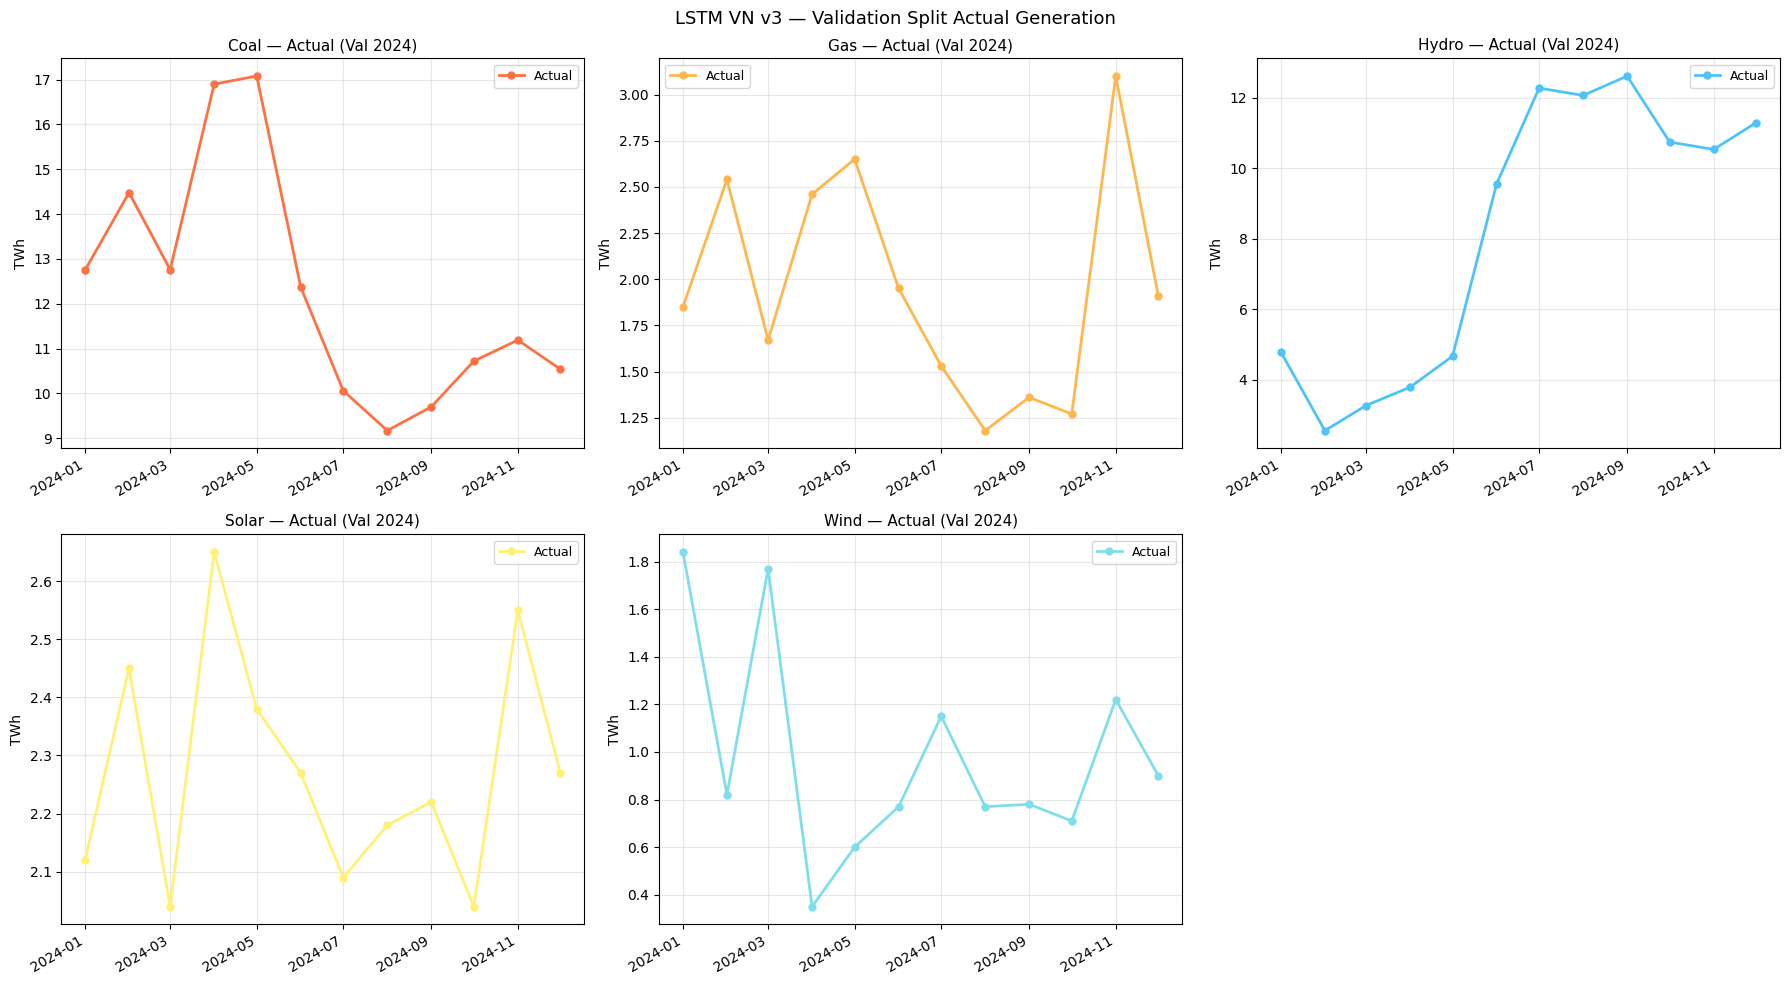

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — VISUALIZE: Actual vs Predicted per series
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.dates as mdates

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d',
    'Hydro': '#4fc3f7', 'Solar': '#fff176', 'Wind': '#80deea',
}

df_val = df_vn[df_vn['time_idx'] > training_cutoff].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ser in enumerate(CFG['fine_tune_series']):
    ax = axes[i]
    sub = df_val[df_val['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')
    ax.plot(sub['date'], sub['generation_TWh'], 'o-',
            color=color, linewidth=2, markersize=5, label='Actual')
    ax.set_title(f'{ser} — Actual (Val 2024)', fontsize=11)
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

if len(CFG['fine_tune_series']) < len(axes):
    for ax in axes[len(CFG['fine_tune_series']):]:
        ax.set_visible(False)

plt.suptitle('LSTM VN v3 — Validation Split Actual Generation', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — SAVE CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import json
import os

# ── Convert toàn bộ object → JSON serializable ─────────────────────────────
def to_serializable(obj):
    import numpy as np
    import torch

    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    return obj

# ── Build config ───────────────────────────────────────────────────────────
vn_config = {
    'fine_tune_series'          : CFG['fine_tune_series'],
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus)',
    'hidden_size'               : CFG['hidden_size'],
    'rnn_layers'                : CFG['rnn_layers'],
    'phase1_lr'                 : CFG['phase1_lr'],
    'phase2_lr'                 : CFG['phase2_lr'],
    'phase1_val_loss'           : float(ckpt_p1.best_model_score),
    'phase2_val_loss'           : float(ckpt_p2.best_model_score),
    'metrics'                   : {
        'mae'  : mae,
        'rmse' : rmse,
        'smape': smape,
        'wape' : wape,
        'r2'   : r2
    },
    'time_varying_known_reals'  : TIME_VARYING_KNOWN_REALS,
}

# ── Convert toàn bộ config ─────────────────────────────────────────────────
vn_config = to_serializable(vn_config)

# ── Define path ────────────────────────────────────────────────────────────
cfg_path = CKPT_DIR / 'lstm_vn_v3_config.json'

# Tạo folder nếu chưa tồn tại
os.makedirs(os.path.dirname(cfg_path), exist_ok=True)

# ── Save JSON ──────────────────────────────────────────────────────────────
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(vn_config, f, indent=2, ensure_ascii=False)

print(f'✅ Config saved → {cfg_path}')

# ── Gợi ý ─────────────────────────────────────────────────────────────────
print()
print('Gợi ý cải thiện thêm:')
print('  1. Nếu WAPE > 20%: tăng phase2_epochs, giảm phase2_lr xuống 1e-5')
print('  2. Nếu Wind/Solar RMSE cao: thêm gen_lag_6 vào known_reals')
print('  3. Không nên fine-tune Other fossil (73% zeros, không học được)')

✅ Config saved → checkpoint\lstm_vn_v3_config.json

Gợi ý cải thiện thêm:
  1. Nếu WAPE > 20%: tăng phase2_epochs, giảm phase2_lr xuống 1e-5
  2. Nếu Wind/Solar RMSE cao: thêm gen_lag_6 vào known_reals
  3. Không nên fine-tune Other fossil (73% zeros, không học được)


: 